In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
# jaccard of IO and labor flow industry-region connections
#jacc_df = pd.read_csv("../outputs/region_region_jaccards.csv", sep=";")
jacc_df = pd.read_csv("../outputs/region_region_jaccards_rca.csv", sep=";")

In [12]:
# region codes for plots
region_codes = pd.read_csv("../data/oc_2022_november/region_codes.csv", sep=";")
region_codes = region_codes[region_codes["megye_nev"] != "fovaros"]
region_codes = region_codes[["megye_kod", "megye_nev"]].drop_duplicates().iloc[:20]

jacc_df = pd.merge(
    jacc_df,
    region_codes,
    left_on="region1",
    right_on="megye_kod",
    how="left"
)
jacc_df = pd.merge(
    jacc_df,
    region_codes,
    left_on="region2",
    right_on="megye_kod",
    how="left",
    suffixes=["1", "2"]
)

In [13]:
# set diagonal to 0 for io_io and lab_lab connections
jacc_df["jaccard_io_io"] = jacc_df["jaccard_io_io"].replace(1, 0)
jacc_df["jaccard_lab_lab"] = jacc_df["jaccard_lab_lab"].replace(1, 0)

In [14]:
def similarity_matrix(df, key_cols, sort_matrix, heatmap, colorway, cmap_lims, title, size, ax=None):
    table = df[key_cols]
    table = pd.pivot_table(
        table,
        values=key_cols[2],
        index=[key_cols[1]],
        columns=[key_cols[0]],
        aggfunc=np.mean,
        margins=True,
        margins_name='total'
    )

    table = table\
                .sort_values(by=["total"], ascending=False, axis=0)\
                .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    # heatmap -- optional
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=True, cmap=colorway, ax=ax)
        ax.collections[0].set_clim(cmap_lims)  
        ax.set_title(title, size=size)
        ax.set_xlabel("", size=size)
        ax.set_ylabel("", size=size)

In [15]:
jacc_df["jaccard_io_labor"].mean()

0.193305

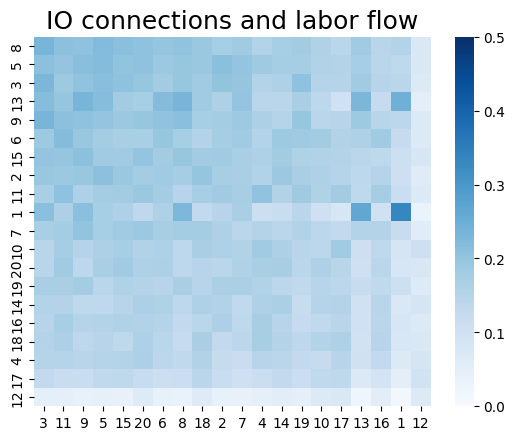

In [6]:
similarity_matrix(
    jacc_df,
    key_cols=["region1", "region2", "jaccard_io_labor"],
    #key_cols=["megye_nev1", "megye_nev2", "jaccard_io_io"],
    #key_cols=["megye_nev1", "megye_nev2", "jaccard_lab_lab"],
    sort_matrix=True,
    heatmap=True,
    colorway="Blues",
    cmap_lims=[0, 0.5],
    title="IO connections and labor flow",
    size=18
)

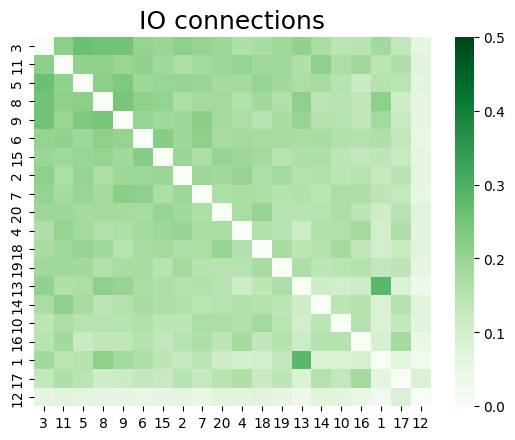

In [40]:
similarity_matrix(
    jacc_df,
    key_cols=["region1", "region2", "jaccard_io_io"],
    sort_matrix=True,
    heatmap=True,
    colorway="Greens",
    cmap_lims=[0, 0.5],
    title="IO connections",
    size=18
)  

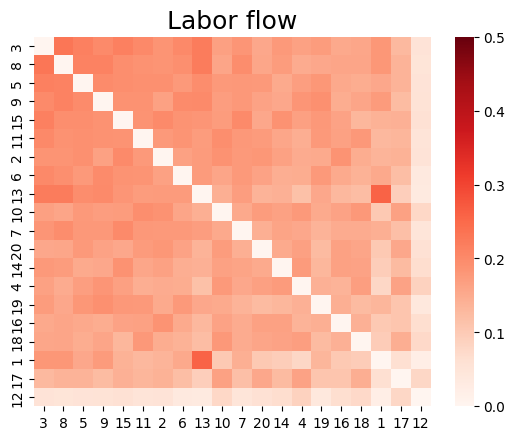

In [41]:
similarity_matrix(
    jacc_df,
    key_cols=["region1", "region2", "jaccard_lab_lab"],
    sort_matrix=True,
    heatmap=True,
    colorway="Reds",
    cmap_lims=[0, 0.5],
    title="Labor flow",
    size=18
)  

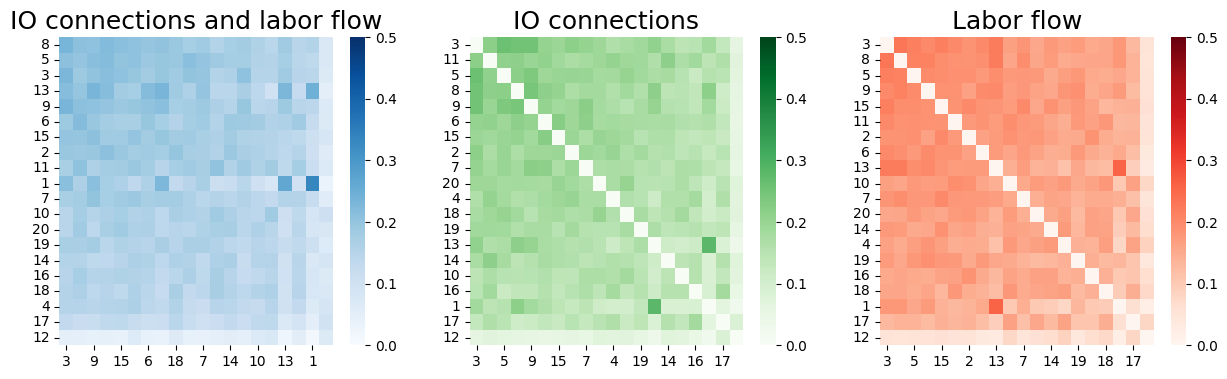

In [42]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

common_fontsize = 18
cmap_limits = [0, 0.5]

similarity_matrix(
    jacc_df,
    key_cols=["region1", "region2", "jaccard_io_labor"],
    sort_matrix=True,
    heatmap=True,
    colorway="Blues",
    cmap_lims=cmap_limits,
    title="IO connections and labor flow",
    size=common_fontsize,
    ax=ax[0]
)

similarity_matrix(
    jacc_df,
    key_cols=["region1", "region2", "jaccard_io_io"],
    sort_matrix=True,
    heatmap=True,
    colorway="Greens",
    cmap_lims=cmap_limits,
    title="IO connections",
    size=common_fontsize,
    ax=ax[1]
)

similarity_matrix(
    jacc_df,
    key_cols=["region1", "region2", "jaccard_lab_lab"],
    sort_matrix=True,
    heatmap=True,
    colorway="Reds",
    cmap_lims=cmap_limits,
    title="Labor flow",
    size=common_fontsize,
    ax=ax[2]
)  


In [2]:
# firm level ties -- crosstables
ctab = pd.read_csv("../data/oc_2023_april_desc_and_regr/desc_table5_tie_overlap_general_crosstab.csv", sep=";")

In [6]:
# N_share
ctab["group_total"] = ctab.groupby("geography")["N"].transform("sum")
ctab["N_share"] = ctab["N"] / ctab["group_total"]

In [7]:
ctab

,supplier01,labor_source01,N,geography,group_total,N_share
0,0,0,1026793,full,2169302,0.473329
1,1,0,826875,full,2169302,0.381171
2,0,1,306849,full,2169302,0.141451
3,1,1,8785,full,2169302,0.004050
4,0,0,404116,nuts3,863666,0.467908
5,1,0,305201,nuts3,863666,0.353379
6,0,1,148431,nuts3,863666,0.171862
7,1,1,5918,nuts3,863666,0.006852
8,0,0,141708,nuts4,310660,0.456151
9,1,0,103969,nuts4,310660,0.334671


In [13]:
# IO and labor ties -- industry-region
ir_df = pd.read_csv("../data/oc_2023_march_labor/m01_ir_ir_el_output_OC.csv", sep=";")

# generate industry-region IDs
ir_df["ir_id1"] = ir_df["reg1"].astype(str) + "-" + ir_df["ind1"].astype(str)
ir_df["ir_id2"] = ir_df["reg2"].astype(str) + "-" + ir_df["ind2"].astype(str)

In [14]:
# drop outliers..
ir_df = ir_df[ir_df["nr_labor_ties"]<2000]

In [19]:
buy_ties = (ir_df["nr_buy_ties"] > 0).astype(int)
ir_df["buy_ties01"] = buy_ties
labor_ties = (ir_df["nr_labor_ties"] > 0).astype(int)
ir_df["labor_ties01"] = labor_ties

In [23]:
# relative -- total number of connections?
ir_df[["buy_ties01", "labor_ties01"]].value_counts().reset_index()

,buy_ties01,labor_ties01,0
0,1,0,220098
1,0,1,89666
2,1,1,47278


In [ ]:
# inside region?


In [2]:
# parameters
reg = "megye"
ind = 3

In [3]:
# load data
tr_df = pd.read_csv("../data/oc_2022_november/transactions_indreg_nace3d_megye.csv", sep=";")
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_megye.csv", sep=";")

In [4]:
# generate industry-region ids
tr_df["ir_id1"] = tr_df["megye_kod1"].astype(str) + "-" + tr_df["nace3d1"].astype(str)
tr_df["ir_id2"] = tr_df["megye_kod2"].astype(str) + "-" + tr_df["nace3d2"].astype(str)
mne_df["ir_id"] = mne_df["megye_kod"].astype(str) + "-" + mne_df["nace3d"].astype(str)

In [5]:
# combine data
tr_df = pd.merge(
    tr_df,
    mne_df[["ir_id", "mne_dom_25", "mne_dom_50", "mne_dom_75"]],
    left_on=["ir_id1"],
    right_on=["ir_id"],
    how="left"
)
tr_df = pd.merge(
    tr_df,
    mne_df[["ir_id", "mne_dom_25", "mne_dom_50", "mne_dom_75"]],
    left_on="ir_id2",
    right_on=["ir_id"],
    how="left",
    suffixes=["_1", "_2"]
)

In [6]:
def ties_across_groups(df, index_col, column_col, normalized, heatmap, fontsize, ax=None):
    """aggregated connections patterns in matrices"""
    # dataframe prep
    df["tie"] = 1
    df = df.drop_duplicates(subset=["ir_id1", "ir_id2"])

    # pivot table construction
    table = pd.pivot_table(
        df,
        values="tie",
        index=index_col,
        columns=column_col,
        aggfunc=np.sum
    ).sum().sum()
    return table

ties_across_groups(tr_df, index_col="mne_dom_50_1", column_col="mne_dom_50_2", normalized=True, heatmap=True, fontsize=20) 

68690

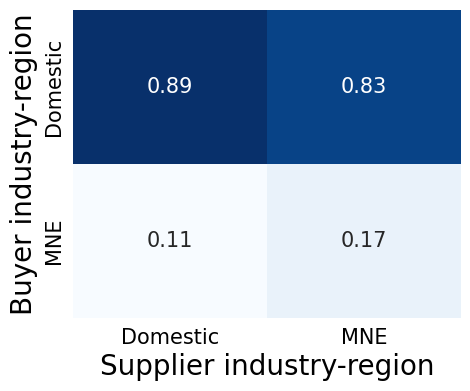

In [11]:
def ties_across_groups(df, index_col, column_col, normalized, heatmap, fontsize, ax=None):
    """aggregated connections patterns in matrices"""
    # dataframe prep
    df["tie"] = 1
    df = df.drop_duplicates(subset=["ir_id1", "ir_id2"])

    # pivot table construction
    table = pd.pivot_table(
        df,
        values="tie",
        index=index_col,
        columns=column_col,
        aggfunc=np.sum
    )
    
    if normalized == True:
        table = table / table.sum()
    else:
        table = table
    
    # visualization option
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap="Blues", annot=True, annot_kws={"fontsize":fontsize-5}, fmt=".2f", ax=ax)
        ax.set_xlabel("Supplier industry-region", size=fontsize)
        ax.set_ylabel("Buyer industry-region", size=fontsize)
        ax.set_xticklabels(["Domestic", "MNE"], size=fontsize-5)
        ax.set_yticklabels(["Domestic", "MNE"], size=fontsize-5)
        ax.tick_params(left = False, bottom = False)


fig, ax = plt.subplots(1,1, figsize=(5,4))
ties_across_groups(tr_df, index_col="mne_dom_50_1", column_col="mne_dom_50_2", normalized=True, heatmap=True, fontsize=20, ax=ax)

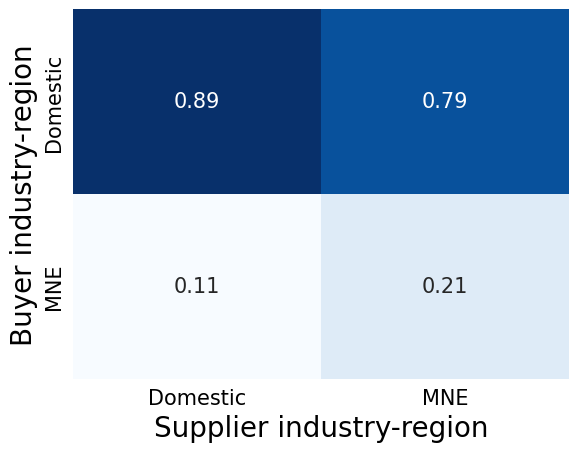

In [13]:
# local ties ONLY
local_tr_df = tr_df[tr_df["megye_kod1"]==tr_df["megye_kod2"]].copy()
ties_across_groups(local_tr_df, index_col="mne_dom_50_1", column_col="mne_dom_50_2", normalized=True, heatmap=True, fontsize=20)